In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
ticker = "AAPL"
data = yf.download(
    ticker,
    start = "2021-01-01",
    end = "2026-01-01"
)
print(f"data:{data.head}")

[*********************100%***********************]  1 of 1 completed

data:<bound method NDFrame.head of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.740868  129.821783  123.166001  129.734338  143301900
2021-01-05  127.295494  128.004807  124.788643  125.235607   97664900
2021-01-06  123.010498  127.334331  122.796735  124.098745  155088000
2021-01-07  127.208054  127.897930  124.234815  124.720639  109578200
2021-01-08  128.305984  128.869542  126.537580  128.675200  105158200
...                ...         ...         ...         ...        ...
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600
2025-12-31  271.355835  273.172467  271.246054  272.553

In [2]:
data.shape

(1255, 5)

In [3]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [4]:
data.info

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.740868  129.821783  123.166001  129.734338  143301900
2021-01-05  127.295494  128.004807  124.788643  125.235607   97664900
2021-01-06  123.010498  127.334331  122.796735  124.098745  155088000
2021-01-07  127.208054  127.897930  124.234815  124.720639  109578200
2021-01-08  128.305984  128.869542  126.537580  128.675200  105158200
...                ...         ...         ...         ...        ...
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600
2025-12-31  271.355835  273.172467  271.246054  272.553622

In [6]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [15]:
df = data.copy()
df["Target"] = df["Close"].shift(-1)

In [16]:
df.head

<bound method NDFrame.head of Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2021-01-04  125.740868  129.821783  123.166001  129.734338  143301900   
2021-01-05  127.295494  128.004807  124.788643  125.235607   97664900   
2021-01-06  123.010498  127.334331  122.796735  124.098745  155088000   
2021-01-07  127.208054  127.897930  124.234815  124.720639  109578200   
2021-01-08  128.305984  128.869542  126.537580  128.675200  105158200   
...                ...         ...         ...         ...        ...   
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600   
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800   
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200   
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600   
2025-12-31  271.35583

In [17]:
df.tail

<bound method NDFrame.tail of Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2021-01-04  125.740868  129.821783  123.166001  129.734338  143301900   
2021-01-05  127.295494  128.004807  124.788643  125.235607   97664900   
2021-01-06  123.010498  127.334331  122.796735  124.098745  155088000   
2021-01-07  127.208054  127.897930  124.234815  124.720639  109578200   
2021-01-08  128.305984  128.869542  126.537580  128.675200  105158200   
...                ...         ...         ...         ...        ...   
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600   
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800   
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200   
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600   
2025-12-31  271.35583

In [18]:
df= df.dropna()

In [19]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
Target            0
dtype: int64

In [21]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

In [22]:
split_index = int(len(df) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

In [24]:
print(X_train.shape)
print(X_test.shape)

(1003, 4)
(251, 4)


In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
prediction = model.predict(X_test)

In [28]:
print(prediction[:5])
print(y_test.head())

[250.62503354 249.11564682 241.40709537 241.45275226 244.49448138]
Date
2024-12-30    248.830200
2024-12-31    242.301956
2025-01-02    241.815033
2025-01-03    243.444595
2025-01-06    240.672318
Name: Target, dtype: float64


In [32]:
from sklearn.metrics import mean_absolute_error,r2_score
mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)
print("mae:",mae)
print("r2:",r2)

mae: 3.092950679418398
r2: 0.9708169299824008


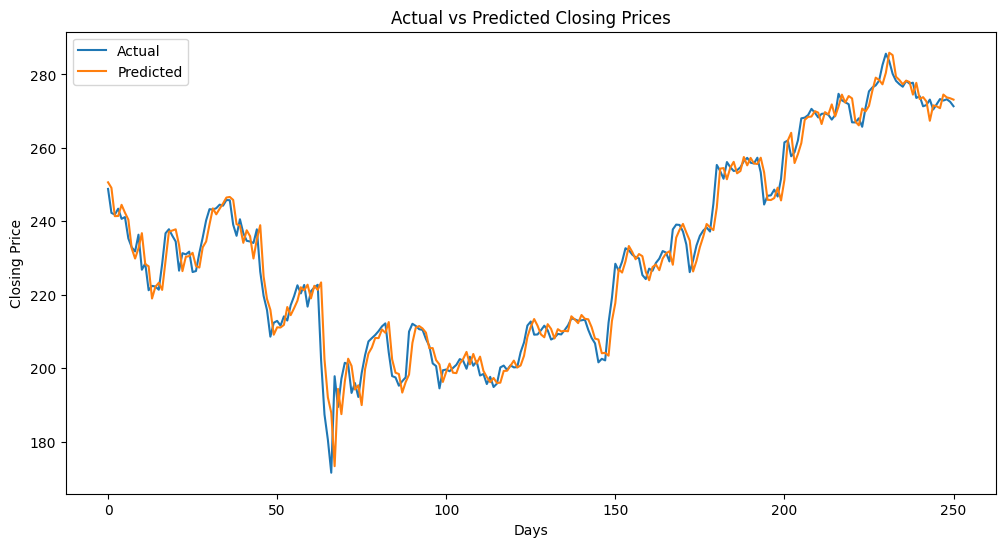

In [37]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")

plt.plot(prediction, label="Predicted")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.title("Actual vs Predicted Closing Prices")

plt.legend()

plt.show()

In [40]:
results = pd.DataFrame({"Actual":y_test.values,
                        "Predicted": prediction})
results.head(10)

,Actual,Predicted
0,248.830200,250.625034
1,242.301956,249.115647
2,241.815033,241.407095
3,243.444595,241.452752
4,240.672318,244.494481
5,241.159210,242.358170
6,235.346359,240.466583
7,232.911911,232.611914
8,231.799042,229.858709
9,236.359879,232.641008
